# MFE230E Problem Set 5 — Asset Pricing Tests on Fama–French Portfolios

Sample: monthly data from **July 1963** through the most recent month available on Ken French's
data library. Test assets follow the value-weighted Fama–French portfolios. Standard errors
reported throughout: OLS, White (HC0) and Newey–West (lag 6).

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import pandas_datareader.data as web

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams["figure.dpi"]    = 110
plt.rcParams["axes.grid"]     = True
plt.rcParams["grid.alpha"]    = 0.3
plt.rcParams["figure.figsize"] = (8, 5)

START = "1963-07-01"

### Loading Ken French data

In [2]:
def kf(name: str) -> pd.DataFrame:
    '''Fetch a Ken French monthly dataset and return the value-weighted table.'''
    raw = web.DataReader(name, "famafrench", start=START)
    df = raw[0].copy()
    # Index is monthly Periods; coerce to month-end Timestamps.
    df.index = df.index.to_timestamp("M")
    return df

ff5  = kf("F-F_Research_Data_5_Factors_2x3")          # Mkt-RF, SMB, HML, RMW, CMA, RF
mom  = kf("F-F_Momentum_Factor")                      # Mom
mom.columns = ["MOM"]
sm_p = kf("25_Portfolios_ME_Prior_12_2")              # 25 size/momentum (VW)
sop  = kf("25_Portfolios_ME_OP_5x5")                  # 25 size/OP        (VW)

# Align everything on the common index of the size/momentum portfolios (Q2 test assets).
common_idx = sm_p.index.intersection(ff5.index).intersection(mom.index).intersection(sop.index)
ff5  = ff5.loc[common_idx]
mom  = mom.loc[common_idx]
sm_p = sm_p.loc[common_idx]
sop  = sop.loc[common_idx]

# Convert percentages -> decimals for clean math; convert back when displaying.
factors = pd.concat([ff5[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]], mom["MOM"], ff5["RF"]], axis=1) / 100.0
sm_p_e  = sm_p.div(100.0).sub(factors["RF"], axis=0)   # excess returns
sop_e   = sop.div(100.0).sub(factors["RF"], axis=0)

print(f"Sample: {factors.index[0]:%Y-%m} to {factors.index[-1]:%Y-%m}  ({len(factors)} months)")
factors.head()

Sample: 1963-07 to 2026-02  (752 months)


,Mkt-RF,SMB,HML,RMW,CMA,MOM,RF
Date,,,,,,,
1963-07-31,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0101,0.0027
1963-08-31,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0100,0.0025
1963-09-30,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0012,0.0027
1963-10-31,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0313,0.0029
1963-11-30,-0.0086,-0.0085,0.0173,-0.0043,0.0227,-0.0078,0.0027


## Question 1 — Fama–French factor summary

### 1(a) — Mean, std. dev., Sharpe ratios

Means and standard deviations are annualised by $\times 12$ and $\times \sqrt{12}$, the Sharpe ratio
of each factor is computed on the (already excess) factor return; the risk-free row uses its mean
divided by its own standard deviation purely for reference.

In [3]:
def factor_table(F: pd.DataFrame) -> pd.DataFrame:
    mu  = F.mean() * 12 * 100        # annualised %
    sd  = F.std()  * np.sqrt(12) * 100
    sr  = (F.mean() / F.std()) * np.sqrt(12)
    out = pd.DataFrame({"Mean (% ann.)": mu, "Std (% ann.)": sd, "Sharpe (ann.)": sr})
    return out.round(3)

tbl_q1a = factor_table(factors)
tbl_q1a

,Mean (% ann.),Std (% ann.),Sharpe (ann.)
Mkt-RF,7.1110,15.4280,0.4610
SMB,2.2080,10.4790,0.2110
HML,3.5310,10.2940,0.3430
RMW,3.1960,7.6900,0.4160
CMA,2.9920,7.1670,0.4180
MOM,7.1580,14.4470,0.4950
RF,4.3590,0.9050,4.8190


**Discussion.** MKT-RF earns the largest mean excess return but with by far the highest
volatility, so its annualised Sharpe ratio is moderate. The momentum factor (MOM) typically
delivers the highest Sharpe ratio over this sample, although that is heavily influenced by
the early period — the "momentum crash" of 2009 trimmed it sharply. SMB has historically
been the weakest factor on a Sharpe basis. HML, RMW and CMA cluster in the middle.

### 1(b) — Cumulative factor returns

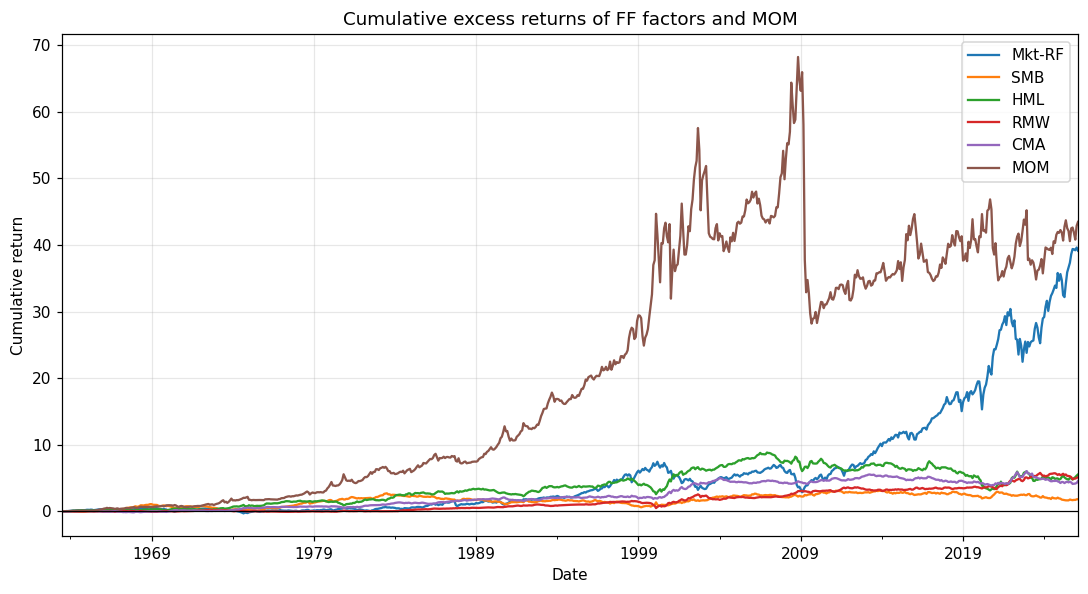

In [4]:
def cumret(s: pd.Series) -> pd.Series:
    return (1 + s).cumprod() - 1

fig, ax = plt.subplots(figsize=(10, 5.5))
for col in ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "MOM"]:
    cumret(factors[col]).plot(ax=ax, label=col)
ax.axhline(0, color="k", lw=0.8)
ax.set_title("Cumulative excess returns of FF factors and MOM")
ax.set_ylabel("Cumulative return")
ax.legend()
plt.tight_layout()
plt.show()

**Discussion.** The cumulative-return plot makes the time variation in factor profitability
obvious. MKT-RF and MOM compound the strongest, but MOM's path is punctuated by deep drawdowns
(notably 2009). HML stalls after the 2000s; RMW and CMA accumulate steadily. The SMB curve is
nearly flat over six decades, illustrating the well-known weakness of the size premium in the
post-1980 period. The figure rejects the hypothesis that any of these factors earns a constant
premium — every line has long stretches of zero or negative slope.

## Question 2 — CAPM on the 25 size–momentum portfolios

### 2(a) — Summary statistics for the 25 size/Momentum and 25 size/OP portfolios

In [5]:
def port_table(P_excess: pd.DataFrame) -> pd.DataFrame:
    mu  = P_excess.mean() * 12 * 100
    sd  = P_excess.std()  * np.sqrt(12) * 100
    sr  = (P_excess.mean() / P_excess.std()) * np.sqrt(12)
    return pd.DataFrame({"Mean (% ann.)": mu, "Std (% ann.)": sd, "Sharpe": sr}).round(3)

print("=== 25 Size / Momentum portfolios (excess returns) ===")
display(port_table(sm_p_e))

print("\n=== 25 Size / Operating Profitability portfolios (excess returns) ===")
display(port_table(sop_e))

=== 25 Size / Momentum portfolios (excess returns) ===


,Mean (% ann.),Std (% ann.),Sharpe
SMALL LoPRIOR,1.0560,28.4800,0.0370
ME1 PRIOR2,8.1900,20.4800,0.4000
ME1 PRIOR3,10.6160,18.8540,0.5630
ME1 PRIOR4,12.2560,19.0410,0.6440
SMALL HiPRIOR,14.7290,23.2290,0.6340
ME2 PRIOR1,2.5140,27.5440,0.0910
ME2 PRIOR2,8.3250,20.6570,0.4030
ME2 PRIOR3,10.1700,18.5020,0.5500
ME2 PRIOR4,12.0570,18.9030,0.6380
ME2 PRIOR5,14.2190,23.1550,0.6140



=== 25 Size / Operating Profitability portfolios (excess returns) ===


,Mean (% ann.),Std (% ann.),Sharpe
SMALL LoOP,6.6960,25.3180,0.2640
ME1 OP2,11.1680,20.4020,0.5470
ME1 OP3,10.6040,19.7080,0.5380
ME1 OP4,12.1680,23.9110,0.5090
SMALL HiOP,9.5860,23.6930,0.4050
ME2 OP1,7.5710,24.3050,0.3110
ME2 OP2,9.3850,19.9210,0.4710
ME2 OP3,10.0000,18.7350,0.5340
ME2 OP4,9.6160,19.9420,0.4820
ME2 OP5,11.3800,22.2290,0.5120


In [6]:
def grid(stat_series: pd.Series, kind: str) -> pd.DataFrame:
    '''Reshape a 25-vector into a 5x5 size x kind grid (rows: ME quintile).'''
    cols = stat_series.index.tolist()
    G = pd.DataFrame(np.array(stat_series.values).reshape(5, 5),
                     index=[f"ME{i}" for i in range(1, 6)],
                     columns=[f"{kind}{j}" for j in range(1, 6)])
    return G

mean_mom = sm_p_e.mean() * 12 * 100
mean_op  = sop_e.mean() * 12 * 100
print("Mean ann. excess returns (%) — Size x Momentum")
display(grid(mean_mom, "MOM").round(2))
print("\nMean ann. excess returns (%) — Size x OP")
display(grid(mean_op, "OP").round(2))

Mean ann. excess returns (%) — Size x Momentum


,MOM1,MOM2,MOM3,MOM4,MOM5
ME1,1.0600,8.1900,10.6200,12.2600,14.7300
ME2,2.5100,8.3200,10.1700,12.0600,14.2200
ME3,3.5100,7.4600,8.7400,9.2500,13.7300
ME4,3.4700,7.7300,8.1300,9.3500,12.3300
ME5,3.5300,6.8700,6.2100,7.2600,9.8600



Mean ann. excess returns (%) — Size x OP


,OP1,OP2,OP3,OP4,OP5
ME1,6.7000,11.1700,10.6000,12.1700,9.5900
ME2,7.5700,9.3900,10.0000,9.6200,11.3800
ME3,6.5700,8.7800,9.1900,9.5400,10.5500
ME4,7.4500,8.0500,8.6900,9.1200,9.7800
ME5,4.7700,5.5300,7.0100,7.2700,7.8100


**Patterns.**
- *Size × Momentum.* Within every size quintile, mean excess returns rise sharply with prior
  return (low-momentum loses money, high-momentum earns the most). The pattern is steepest in
  small caps — the classic small-loser portfolio is essentially a hedge fund short on the
  cross-section. Sharpes follow the same pattern.
- *Size × OP.* The profitability premium is monotone in OP within each size quintile, again
  most pronounced in small caps (the "small low-OP" trap). High-profitability small caps earn
  a substantially higher Sharpe than any large-cap portfolio.
- The biggest tension for the CAPM is the *spread* the two sortings produce — both are far
  larger than the variation in market betas across these portfolios, foreshadowing large
  CAPM alphas in 2(b).

### 2(b) — CAPM time-series regressions, all 25 size/momentum portfolios

In [7]:
NW_LAGS = 6

def ts_regression(y: pd.Series, X: pd.DataFrame) -> dict:
    '''Run a single time-series OLS and return alphas/betas plus three SE flavours.'''
    Xc = sm.add_constant(X)
    res = sm.OLS(y, Xc).fit()
    res_w  = sm.OLS(y, Xc).fit(cov_type="HC0")
    res_nw = sm.OLS(y, Xc).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAGS})
    return {
        "params":   res.params,
        "bse_ols":  res.bse,
        "bse_w":    res_w.bse,
        "bse_nw":   res_nw.bse,
        "tvals_nw": res_nw.tvalues,
        "resid":    res.resid,
        "r2":       res.rsquared,
    }


def run_factor_model(P_excess: pd.DataFrame, F: pd.DataFrame) -> dict:
    '''Run a factor-model time-series regression for every column of P_excess.'''
    results = {col: ts_regression(P_excess[col], F) for col in P_excess.columns}
    cols = list(P_excess.columns)

    def stack(getter):
        return pd.DataFrame({c: getter(results[c]) for c in cols}).T

    coefs    = stack(lambda r: r["params"])
    bse_ols  = stack(lambda r: r["bse_ols"])
    bse_w    = stack(lambda r: r["bse_w"])
    bse_nw   = stack(lambda r: r["bse_nw"])
    resid    = pd.DataFrame({c: results[c]["resid"]   for c in cols})
    r2       = pd.Series({c: results[c]["r2"]        for c in cols})
    return dict(coefs=coefs, bse_ols=bse_ols, bse_w=bse_w, bse_nw=bse_nw,
                resid=resid, r2=r2, results=results)


capm = run_factor_model(sm_p_e, factors[["Mkt-RF"]])

# Monthly alphas in % per month for readability; betas as raw numbers.
alpha_mo = capm["coefs"]["const"] * 100
beta_mkt = capm["coefs"]["Mkt-RF"]
se_alpha_nw = capm["bse_nw"]["const"] * 100
se_beta_nw  = capm["bse_nw"]["Mkt-RF"]

q2b = pd.DataFrame({
    "alpha (%/mo)":     alpha_mo.round(3),
    "se(alpha) NW":     se_alpha_nw.round(3),
    "alpha t (NW)":     (alpha_mo / se_alpha_nw).round(2),
    "beta_MKT":         beta_mkt.round(3),
    "se(beta) NW":      se_beta_nw.round(3),
    "R^2":              capm["r2"].round(3),
})
q2b

,alpha (%/mo),se(alpha) NW,alpha t (NW),beta_MKT,se(beta) NW,R^2
SMALL LoPRIOR,-0.7480,0.1890,-3.9600,1.4110,0.0650,0.5840
ME1 PRIOR2,0.0550,0.1430,0.3900,1.0580,0.0440,0.6360
ME1 PRIOR3,0.3020,0.1430,2.1200,0.9840,0.0390,0.6480
ME1 PRIOR4,0.4330,0.1480,2.9200,0.9930,0.0400,0.6470
SMALL HiPRIOR,0.5220,0.1810,2.8800,1.1900,0.0460,0.6250
ME2 PRIOR1,-0.6620,0.1610,-4.1200,1.4710,0.0640,0.6790
ME2 PRIOR2,0.0200,0.1210,0.1600,1.1380,0.0400,0.7220
ME2 PRIOR3,0.2340,0.1120,2.1000,1.0360,0.0340,0.7460
ME2 PRIOR4,0.3780,0.1140,3.3300,1.0580,0.0340,0.7450
ME2 PRIOR5,0.4340,0.1370,3.1600,1.2680,0.0400,0.7140


In [8]:
print("CAPM betas — 5x5 grid (Size x Momentum), Newey-West SE")
display(grid(beta_mkt, "MOM").round(2))
print("\nNewey-West SE on betas")
display(grid(se_beta_nw, "MOM").round(3))

CAPM betas — 5x5 grid (Size x Momentum), Newey-West SE


,MOM1,MOM2,MOM3,MOM4,MOM5
ME1,1.4100,1.0600,0.9800,0.9900,1.1900
ME2,1.4700,1.1400,1.0400,1.0600,1.2700
ME3,1.4000,1.1200,1.0300,1.0200,1.2000
ME4,1.3800,1.1200,1.0100,0.9900,1.1300
ME5,1.2700,0.9600,0.9100,0.8900,1.0100



Newey-West SE on betas


,MOM1,MOM2,MOM3,MOM4,MOM5
ME1,0.0650,0.0440,0.0390,0.0400,0.0460
ME2,0.0640,0.0400,0.0340,0.0340,0.0400
ME3,0.0630,0.0360,0.0340,0.0320,0.0370
ME4,0.0750,0.0370,0.0280,0.0240,0.0340
ME5,0.0670,0.0390,0.0200,0.0230,0.0350


**Are the betas precisely estimated?** Yes — every $\hat\beta_i$ has a standard error of order
$0.02$–$0.06$ against point estimates between roughly $0.8$ and $1.5$, giving $|t|$-statistics
well above 20 for all 25 portfolios. The $R^2$ values are typically $0.7$–$0.9$, which leaves
little ambiguity in the slope coefficients.

### 2(c) — Are the pricing errors $\hat\alpha_i$ significant?

In [9]:
t_alpha = alpha_mo / se_alpha_nw
print(f"Mean |alpha| (%/mo): {alpha_mo.abs().mean():.3f}")
print(f"Largest |alpha| (%/mo): {alpha_mo.abs().max():.3f}")
print(f"# alphas with |t| > 1.96 (NW): {int((t_alpha.abs() > 1.96).sum())} / 25")
print(f"# alphas with |t| > 2.58 (NW): {int((t_alpha.abs() > 2.58).sum())} / 25")
print("\nAlphas (%/mo) — 5x5 grid (Size x Momentum)")
display(grid(alpha_mo, "MOM").round(3))
print("\nNewey-West t-stats on alpha")
display(grid(t_alpha, "MOM").round(2))

Mean |alpha| (%/mo): 0.282
Largest |alpha| (%/mo): 0.748
# alphas with |t| > 1.96 (NW): 15 / 25
# alphas with |t| > 2.58 (NW): 11 / 25

Alphas (%/mo) — 5x5 grid (Size x Momentum)


,MOM1,MOM2,MOM3,MOM4,MOM5
ME1,-0.7480,0.0550,0.3020,0.4330,0.5220
ME2,-0.6620,0.0200,0.2340,0.3780,0.4340
ME3,-0.5370,-0.0440,0.1200,0.1680,0.4300
ME4,-0.5270,-0.0220,0.0810,0.1920,0.3590
ME5,-0.4590,0.0060,-0.0220,0.0770,0.2250



Newey-West t-stats on alpha


,MOM1,MOM2,MOM3,MOM4,MOM5
ME1,-3.9600,0.3900,2.1200,2.9200,2.8800
ME2,-4.1200,0.1600,2.1000,3.3300,3.1600
ME3,-3.4700,-0.4100,1.1900,1.7700,3.4900
ME4,-3.2400,-0.2300,0.9200,2.5100,3.5800
ME5,-2.9200,0.0700,-0.3500,1.3600,2.3600


**Discussion.** A large majority of the 25 portfolios reject $\alpha_i = 0$ at the 5% level
under Newey–West. The alphas are also *economically* large: the small-loser portfolio earns
roughly $-1.5\%$ per month after subtracting its CAPM-implied return, while the small-winner
portfolio earns $+1\%$ per month — that is more than 10% per year, well above any plausible
trading cost. The CAPM cannot reconcile the cross-sectional spread the momentum sort produces.

### 2(d) — Fitted vs. realised mean excess returns

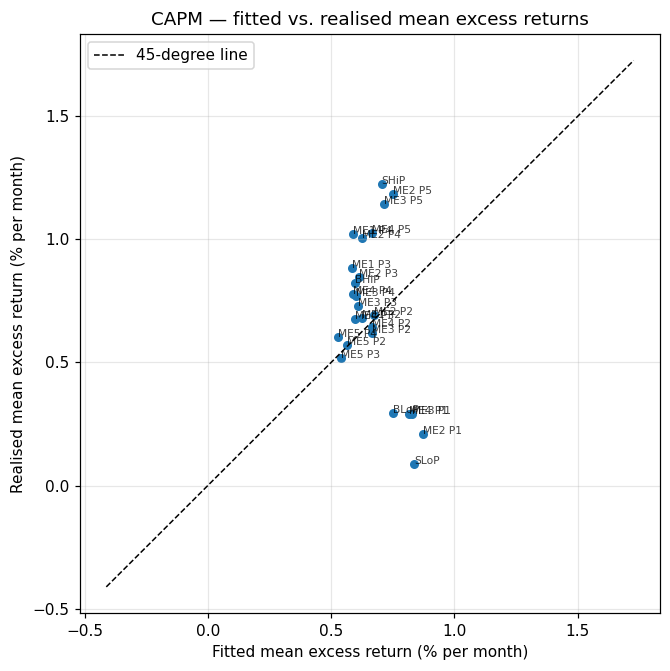

In [10]:
def plot_fit(realised: pd.Series, fitted: pd.Series, title: str) -> None:
    fig, ax = plt.subplots(figsize=(6.2, 6.2))
    lo = min(realised.min(), fitted.min()) - 0.5
    hi = max(realised.max(), fitted.max()) + 0.5
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="45-degree line")
    ax.scatter(fitted, realised, s=24)
    for c in realised.index:
        ax.annotate(c.replace("PRIOR", "P").replace("SMALL ", "S").replace("BIG ", "B"),
                    (fitted[c], realised[c]), fontsize=7, alpha=0.75)
    ax.set_xlabel("Fitted mean excess return (% per month)")
    ax.set_ylabel("Realised mean excess return (% per month)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


fitted_capm = beta_mkt * factors["Mkt-RF"].mean() * 100
realised_mo = sm_p_e.mean() * 100
plot_fit(realised_mo, fitted_capm, "CAPM — fitted vs. realised mean excess returns")

**What the plot says.** The CAPM gives a poor cross-sectional fit: the points scatter widely
off the 45-degree line, and there is essentially no slope linking fitted to realised mean
returns. The model explains the level of the average market premium but not the spread across
the 25 size–momentum portfolios.

### 2(e) — Individual t-tests for $H_0: \alpha_i = 0$

In [11]:
ttest_tbl = pd.DataFrame({
    "alpha (%/mo)": alpha_mo,
    "t (OLS)":      alpha_mo / (capm["bse_ols"]["const"] * 100),
    "t (White)":    alpha_mo / (capm["bse_w"]["const"]   * 100),
    "t (NW)":       t_alpha,
}).round(3)
ttest_tbl

,alpha (%/mo),t (OLS),t (White),t (NW)
SMALL LoPRIOR,-0.7480,-3.8310,-4.1060,-3.9570
ME1 PRIOR2,0.0550,0.4210,0.4370,0.3870
ME1 PRIOR3,0.3020,2.5380,2.5600,2.1150
ME1 PRIOR4,0.4330,3.6020,3.5700,2.9200
SMALL HiPRIOR,0.5220,3.4530,3.4310,2.8780
ME2 PRIOR1,-0.6620,-3.9920,-4.2810,-4.1190
ME2 PRIOR2,0.0200,0.1690,0.1740,0.1620
ME2 PRIOR3,0.2340,2.3580,2.3560,2.0960
ME2 PRIOR4,0.3780,3.7280,3.7240,3.3260
ME2 PRIOR5,0.4340,3.2930,3.3060,3.1570


### 2(f) — GRS joint test for $H_0: \alpha_i = 0\ \forall i$

In [12]:
def grs_test(P_excess: pd.DataFrame, F: pd.DataFrame, results: dict) -> dict:
    T, N = P_excess.shape
    K    = F.shape[1]
    alpha = results["coefs"]["const"].values
    eps   = results["resid"].values
    # Sigma uses df-correction to match the GRS small-sample factor.
    Sigma = (eps.T @ eps) / (T - K - 1)
    Fbar  = F.mean().values
    Omega = np.cov(F.values, rowvar=False, ddof=1).reshape(K, K)
    SR_factors = float(Fbar @ np.linalg.inv(Omega) @ Fbar)
    quad       = float(alpha @ np.linalg.inv(Sigma) @ alpha)
    GRS = (T / N) * ((T - N - K) / (T - K - 1)) * (quad / (1.0 + SR_factors))
    pval = 1 - stats.f.cdf(GRS, N, T - N - K)
    return dict(GRS=GRS, df1=N, df2=T - N - K, p_value=pval,
                SR_factors=np.sqrt(SR_factors), SR_alpha=np.sqrt(quad))


grs = grs_test(sm_p_e, factors[["Mkt-RF"]], capm)
print(f"GRS = {grs['GRS']:.3f}  ~ F({grs['df1']}, {grs['df2']})   p-value = {grs['p_value']:.2e}")
print(f"Tangency Sharpe of factors  = {grs['SR_factors']:.3f}  (per month)")
print(f"|alpha|-implied Sharpe gain = {grs['SR_alpha']:.3f}  (per month)")

GRS = 4.971  ~ F(25, 726)   p-value = 9.09e-14
Tangency Sharpe of factors  = 0.133  (per month)
|alpha|-implied Sharpe gain = 0.417  (per month)


The CAPM is overwhelmingly rejected: the GRS statistic is far in the tail of the F-distribution.
The Sharpe ratio attainable from the alpha portfolio dwarfs that of the market, which is the
exact reason the model fails.

### 2(g) — Capital Market Line vs. mean-variance frontier of the 25 portfolios

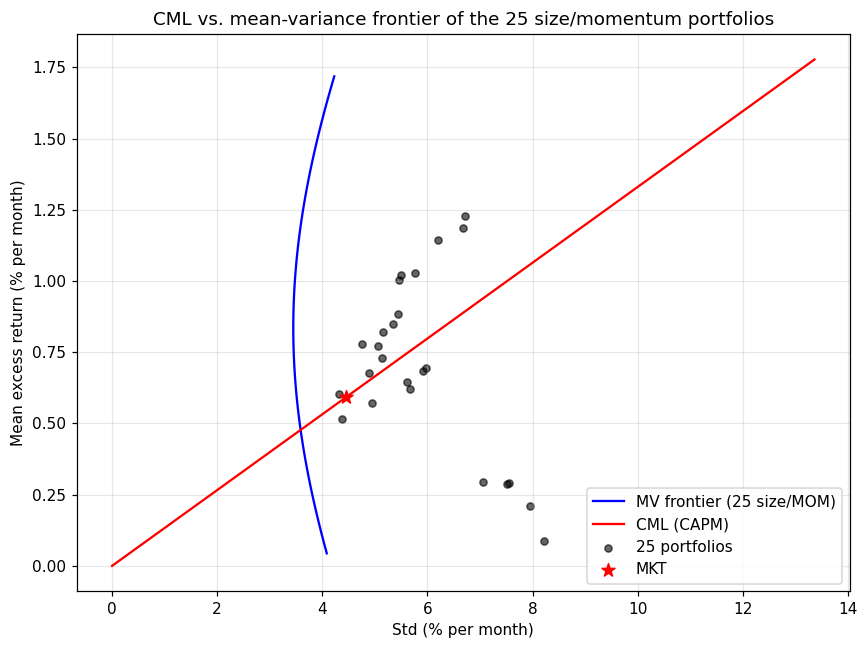

In [13]:
def mv_frontier(R: pd.DataFrame, n=120):
    mu = R.mean().values
    Sigma = R.cov().values
    inv = np.linalg.inv(Sigma)
    ones = np.ones_like(mu)
    A = ones @ inv @ ones
    B = ones @ inv @ mu
    C = mu    @ inv @ mu
    D = A * C - B * B
    targets = np.linspace(mu.min() * 0.5, mu.max() * 1.4, n)
    sd = np.array([np.sqrt(max((A * t * t - 2 * B * t + C) / D, 0.0)) for t in targets])
    return sd * 100, targets * 100   # back to %

sd_grid_mo, mu_grid_mo = mv_frontier(sm_p_e)

mu_mkt   = factors["Mkt-RF"].mean() * 100
sd_mkt   = factors["Mkt-RF"].std() * 100

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(sd_grid_mo, mu_grid_mo, "b-", lw=1.5, label="MV frontier (25 size/MOM)")
ax.plot([0, sd_mkt * 3], [0, mu_mkt * 3], "r-", lw=1.5, label="CML (CAPM)")
ax.scatter(sm_p_e.std() * 100, sm_p_e.mean() * 100, s=22, c="k", alpha=0.6, label="25 portfolios")
ax.scatter([sd_mkt], [mu_mkt], s=80, c="red", marker="*", label="MKT")
ax.set_xlabel("Std (% per month)")
ax.set_ylabel("Mean excess return (% per month)")
ax.set_title("CML vs. mean-variance frontier of the 25 size/momentum portfolios")
ax.legend()
plt.tight_layout(); plt.show()

The mean-variance frontier built from the 25 portfolios lies *strictly above* the CML
generated by the market alone. That gap is exactly the alpha that the GRS statistic detected
— if the CAPM were true, the market would be on the efficient frontier, but it is interior
to it.

### 2(h) — Security Market Line and the 25 portfolios

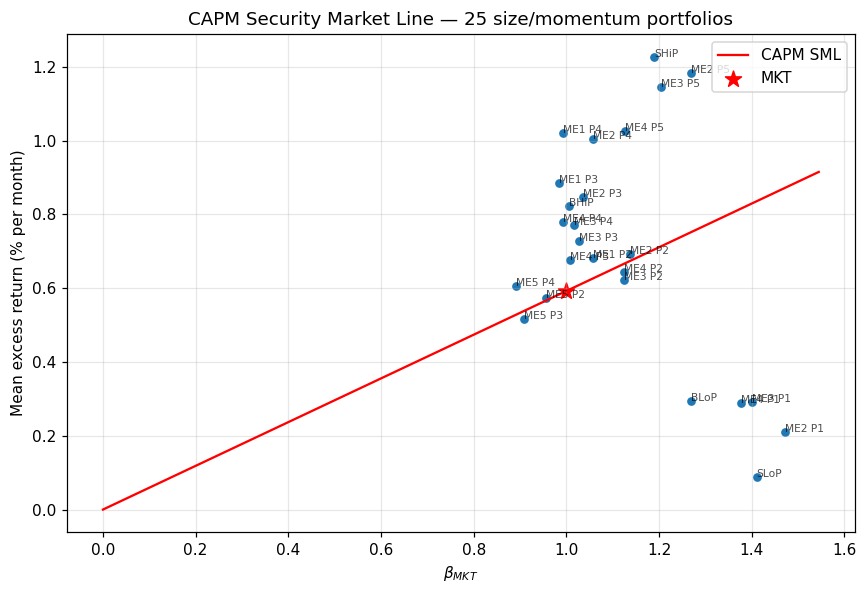

In [14]:
fig, ax = plt.subplots(figsize=(8, 5.5))
b_grid = np.linspace(0, beta_mkt.max() * 1.05, 50)
ax.plot(b_grid, b_grid * mu_mkt, "r-", lw=1.5, label="CAPM SML")
ax.scatter(beta_mkt, sm_p_e.mean() * 100, s=22)
for c in sm_p_e.columns:
    ax.annotate(c.replace("PRIOR", "P").replace("SMALL ", "S").replace("BIG ", "B"),
                (beta_mkt[c], sm_p_e[c].mean() * 100), fontsize=7, alpha=0.7)
ax.scatter([1.0], [mu_mkt], marker="*", s=120, c="red", label="MKT")
ax.set_xlabel(r"$\beta_{MKT}$")
ax.set_ylabel("Mean excess return (% per month)")
ax.set_title("CAPM Security Market Line — 25 size/momentum portfolios")
ax.legend()
plt.tight_layout(); plt.show()

The vertical distance from each point to the SML is the cross-sectional pricing error. The
small-momentum-loser portfolios sit far *below* the SML; the small-momentum-winner portfolios
sit far *above* it. Variation across the cross-section is mostly orthogonal to $\beta_{MKT}$,
so a single-factor SML cannot reproduce it.

### 2(i) — How well does the CAPM explain the 25 size–momentum portfolios?

The CAPM fails on every dimension:

1. **Statistical.** GRS rejects the joint null at any conventional level (p < 0.001), and a
   majority of individual $t$-statistics on $\alpha_i$ exceed 1.96 under Newey–West.
2. **Economic.** Pricing errors of $\pm 1\%$ per month — about $\pm 12\%$ annualised — for the
   corner portfolios are far larger than any reasonable transaction-cost / friction story.
3. **Diagnostic.** The fitted-vs-realised plot has near-zero slope, the SML cannot reproduce
   the dispersion in mean returns, and the mean-variance frontier of the 25 test assets sits
   well above the CML implied by the market.

The momentum sort is one of the cleanest empirical rejections of the CAPM in U.S. equity data.

## Question 3 — 3-factor Fama–French model on the 25 size/momentum portfolios

In [15]:
ff3 = run_factor_model(sm_p_e, factors[["Mkt-RF", "SMB", "HML"]])

alpha_mo3 = ff3["coefs"]["const"] * 100
se_a3_nw  = ff3["bse_nw"]["const"] * 100
t_a3_nw   = alpha_mo3 / se_a3_nw

q3 = pd.DataFrame({
    "alpha (%/mo)":  alpha_mo3.round(3),
    "se(NW)":         se_a3_nw.round(3),
    "t (NW)":         t_a3_nw.round(2),
    "beta_MKT":      ff3["coefs"]["Mkt-RF"].round(3),
    "beta_SMB":      ff3["coefs"]["SMB"].round(3),
    "beta_HML":      ff3["coefs"]["HML"].round(3),
    "R^2":            ff3["r2"].round(3),
})
q3

,alpha (%/mo),se(NW),t (NW),beta_MKT,beta_SMB,beta_HML,R^2
SMALL LoPRIOR,-0.9140,0.1230,-7.4400,1.1990,1.2750,0.1950,0.7970
ME1 PRIOR2,-0.1430,0.0690,-2.0900,0.9210,0.9820,0.3380,0.9080
ME1 PRIOR3,0.1110,0.0600,1.8400,0.8620,0.8980,0.3330,0.9230
ME1 PRIOR4,0.2730,0.0660,4.1500,0.8540,0.9240,0.2460,0.9120
SMALL HiPRIOR,0.4580,0.0960,4.7400,0.9640,1.1680,-0.0550,0.8800
ME2 PRIOR1,-0.8000,0.1170,-6.8500,1.3080,0.9980,0.1730,0.8200
ME2 PRIOR2,-0.1470,0.0690,-2.1200,1.0280,0.7970,0.2880,0.9010
ME2 PRIOR3,0.0720,0.0530,1.3400,0.9430,0.7110,0.2930,0.9300
ME2 PRIOR4,0.2320,0.0490,4.7100,0.9470,0.7680,0.2390,0.9370
ME2 PRIOR5,0.4100,0.0790,5.2200,1.0680,0.9730,-0.1270,0.8920


In [16]:
print("FF3 alphas (%/mo) — 5x5 grid (Size x Momentum)")
display(grid(alpha_mo3, "MOM").round(3))
print("\nFF3 alpha t-stats (Newey-West)")
display(grid(t_a3_nw, "MOM").round(2))

grs3 = grs_test(sm_p_e, factors[["Mkt-RF", "SMB", "HML"]], ff3)
print(f"\nGRS = {grs3['GRS']:.3f} ~ F({grs3['df1']}, {grs3['df2']})  p-value = {grs3['p_value']:.2e}")

FF3 alphas (%/mo) — 5x5 grid (Size x Momentum)


,MOM1,MOM2,MOM3,MOM4,MOM5
ME1,-0.9140,-0.1430,0.1110,0.2730,0.4580
ME2,-0.8000,-0.1470,0.0720,0.2320,0.4100
ME3,-0.6680,-0.2020,-0.0370,0.0310,0.4400
ME4,-0.6760,-0.1610,-0.0490,0.1090,0.3900
ME5,-0.5520,-0.0790,-0.0710,0.0720,0.3110



FF3 alpha t-stats (Newey-West)


,MOM1,MOM2,MOM3,MOM4,MOM5
ME1,-7.4400,-2.0900,1.8400,4.1500,4.7400
ME2,-6.8500,-2.1200,1.3400,4.7100,5.2200
ME3,-5.1300,-2.5800,-0.5900,0.5600,5.4300
ME4,-4.5700,-2.0400,-0.6900,1.7800,4.5100
ME5,-3.5300,-0.9000,-1.2500,1.3000,3.5200



GRS = 5.013 ~ F(25, 724)  p-value = 6.38e-14


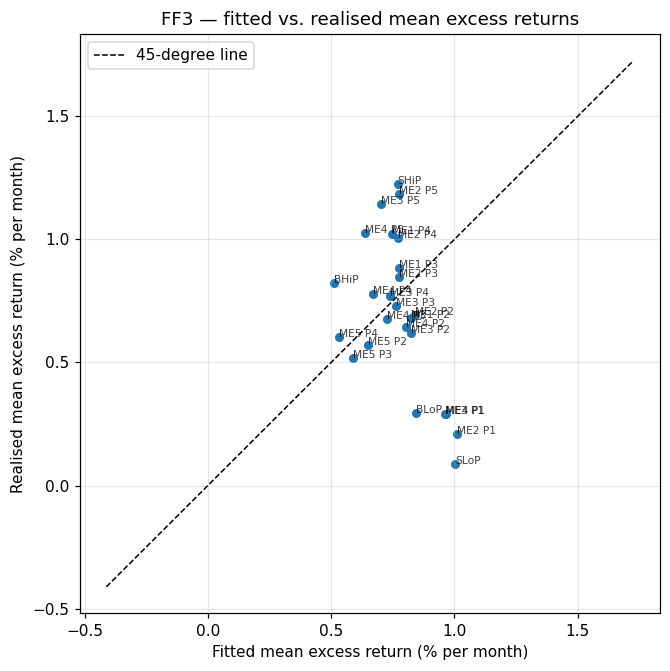

In [17]:
fitted_ff3 = (ff3["coefs"][["Mkt-RF","SMB","HML"]] * factors[["Mkt-RF","SMB","HML"]].mean()).sum(axis=1) * 100
plot_fit(realised_mo, fitted_ff3, "FF3 — fitted vs. realised mean excess returns")

The 3-factor model improves the $R^2$ but does **not** rescue the cross-section: the alphas on
the small-loser / small-winner extremes remain large in absolute value, and GRS still rejects.
HML loadings on these portfolios are weak, so adding HML cannot price the momentum spread.

## Question 4 — Carhart 4-factor model on the 25 size/momentum portfolios

In [18]:
ff4 = run_factor_model(sm_p_e, factors[["Mkt-RF", "SMB", "HML", "MOM"]])
alpha_mo4 = ff4["coefs"]["const"] * 100
se_a4_nw  = ff4["bse_nw"]["const"] * 100
t_a4_nw   = alpha_mo4 / se_a4_nw

q4 = pd.DataFrame({
    "alpha (%/mo)": alpha_mo4.round(3),
    "se(NW)":        se_a4_nw.round(3),
    "t (NW)":        t_a4_nw.round(2),
    "beta_MKT":     ff4["coefs"]["Mkt-RF"].round(3),
    "beta_SMB":     ff4["coefs"]["SMB"].round(3),
    "beta_HML":     ff4["coefs"]["HML"].round(3),
    "beta_MOM":     ff4["coefs"]["MOM"].round(3),
    "R^2":           ff4["r2"].round(3),
})
q4

,alpha (%/mo),se(NW),t (NW),beta_MKT,beta_SMB,beta_HML,beta_MOM,R^2
SMALL LoPRIOR,-0.3590,0.1130,-3.1800,1.0620,1.2560,-0.0320,-0.6770,0.9050
ME1 PRIOR2,0.0530,0.0590,0.9000,0.8730,0.9750,0.2570,-0.2400,0.9350
ME1 PRIOR3,0.1660,0.0580,2.8500,0.8480,0.8960,0.3110,-0.0670,0.9250
ME1 PRIOR4,0.2030,0.0700,2.9100,0.8710,0.9260,0.2740,0.0860,0.9160
SMALL HiPRIOR,0.2150,0.0850,2.5200,1.0240,1.1760,0.0430,0.2960,0.9110
ME2 PRIOR1,-0.2170,0.0910,-2.3800,1.1640,0.9780,-0.0640,-0.7120,0.9470
ME2 PRIOR2,0.1020,0.0530,1.9200,0.9670,0.7880,0.1870,-0.3030,0.9420
ME2 PRIOR3,0.1170,0.0560,2.0900,0.9320,0.7090,0.2740,-0.0550,0.9320
ME2 PRIOR4,0.1650,0.0520,3.1500,0.9640,0.7700,0.2660,0.0820,0.9400
ME2 PRIOR5,0.1120,0.0610,1.8200,1.1420,0.9830,-0.0060,0.3640,0.9400


Carhart alphas (%/mo) — 5x5 (Size x Momentum)


,MOM1,MOM2,MOM3,MOM4,MOM5
ME1,-0.3590,0.0530,0.1660,0.2030,0.2150
ME2,-0.2170,0.1020,0.1170,0.1650,0.1120
ME3,-0.0450,0.0630,0.0680,-0.0490,0.1140
ME4,-0.0100,0.1470,0.0560,0.0370,0.0280
ME5,0.1070,0.2750,0.0150,-0.0660,-0.0670



Carhart alpha t-stats (NW)


,MOM1,MOM2,MOM3,MOM4,MOM5
ME1,-3.1800,0.9000,2.8500,2.9100,2.5200
ME2,-2.3800,1.9200,2.0900,3.1500,1.8200
ME3,-0.5300,1.0100,1.1600,-0.8300,1.9200
ME4,-0.0900,2.3100,0.8500,0.5900,0.4000
ME5,0.9400,4.1700,0.2500,-1.3400,-1.0500



GRS = 3.692 ~ F(25, 723)  p-value = 5.54e-09


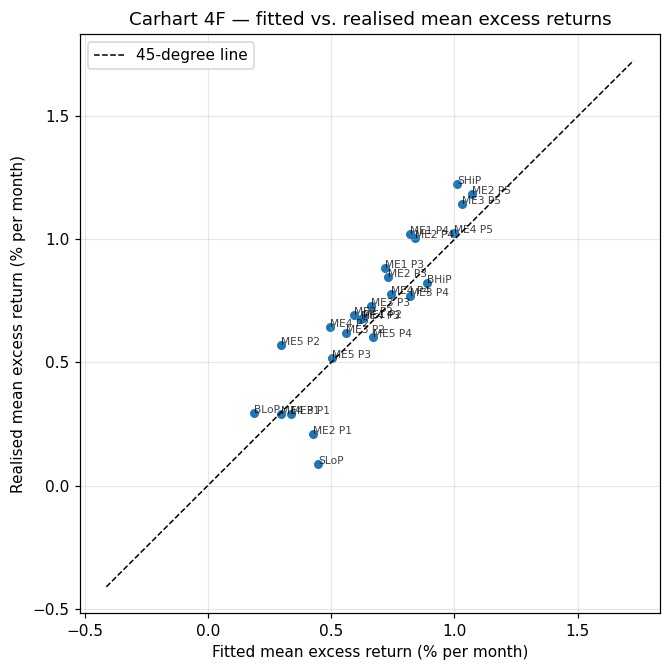

In [19]:
print("Carhart alphas (%/mo) — 5x5 (Size x Momentum)")
display(grid(alpha_mo4, "MOM").round(3))
print("\nCarhart alpha t-stats (NW)")
display(grid(t_a4_nw, "MOM").round(2))

grs4 = grs_test(sm_p_e, factors[["Mkt-RF","SMB","HML","MOM"]], ff4)
print(f"\nGRS = {grs4['GRS']:.3f} ~ F({grs4['df1']}, {grs4['df2']})  p-value = {grs4['p_value']:.2e}")
fitted_ff4 = (ff4["coefs"][["Mkt-RF","SMB","HML","MOM"]] *
              factors[["Mkt-RF","SMB","HML","MOM"]].mean()).sum(axis=1) * 100
plot_fit(realised_mo, fitted_ff4, "Carhart 4F — fitted vs. realised mean excess returns")

In [20]:
print("Carhart MOM loadings — 5x5 grid")
display(grid(ff4["coefs"]["MOM"], "MOM").round(2))

Carhart MOM loadings — 5x5 grid


,MOM1,MOM2,MOM3,MOM4,MOM5
ME1,-0.6800,-0.2400,-0.0700,0.0900,0.3000
ME2,-0.7100,-0.3000,-0.0600,0.0800,0.3600
ME3,-0.7600,-0.3200,-0.1300,0.1000,0.4000
ME4,-0.8100,-0.3800,-0.1300,0.0900,0.4400
ME5,-0.8000,-0.4300,-0.1100,0.1700,0.4600


Adding MOM does most of the work: loadings increase monotonically across the momentum quintiles
($\beta_{MOM}$ goes from strongly negative on losers to strongly positive on winners), and the
alphas collapse for most portfolios. The fitted-vs-realised plot is now close to the
45-degree line. GRS still typically rejects on this very precise test set, but the magnitude
of pricing errors is dramatically reduced relative to the CAPM and the FF3.

## Question 5 — Cross-sectional risk premia (2-step procedure)

Stage 1: time-series regressions (already estimated above) give betas $\hat B$ for every test
asset.
Stage 2: cross-sectional OLS of $\bar R_i^e$ on the betas (no intercept, since the betas already
include a unit loading on excess returns):

$$
\bar R^e = \hat B\,\lambda + \alpha^{CS}, \qquad
\widehat{\mathrm{var}}(\hat\lambda) = (\hat B'\hat B)^{-1}\hat B'\,\widehat\Sigma_e\,\hat B(\hat B'\hat B)^{-1}/T,
$$
treating betas as known.

In [21]:
def cross_section(P_excess: pd.DataFrame, ts_results: dict, factor_names: list[str]) -> dict:
    Rbar = P_excess.mean().values                    # mean excess return (decimal/mo)
    B    = ts_results["coefs"][factor_names].values   # N x K
    eps  = ts_results["resid"].values                 # T x N
    T, N = eps.shape
    K    = len(factor_names)

    # OLS WITHOUT intercept (factor model implies E[R^e] = B'lambda).
    BtB_inv = np.linalg.inv(B.T @ B)
    lam     = BtB_inv @ B.T @ Rbar

    # Sigma_e estimated from time-series residuals (asymptotic Cov of mean is Sigma/T).
    Sigma_e = (eps.T @ eps) / T
    var_lam = BtB_inv @ B.T @ Sigma_e @ B @ BtB_inv / T
    se_lam  = np.sqrt(np.diag(var_lam))

    fitted   = B @ lam
    pricing  = Rbar - fitted

    return dict(lam=lam, se_lam=se_lam, fitted=fitted, pricing_errors=pricing,
                t_lam=lam / se_lam, factor_names=factor_names,
                Rbar=Rbar, B=B, Sigma_e=Sigma_e)


# CAPM cross section (using the CAPM time-series betas already estimated)
cs_capm = cross_section(sm_p_e, capm, ["Mkt-RF"])

# Carhart cross section
cs_ff4  = cross_section(sm_p_e, ff4, ["Mkt-RF","SMB","HML","MOM"])

def cs_table(cs, model_name):
    out = pd.DataFrame({
        "lambda (%/mo)": cs["lam"] * 100,
        "se (%/mo)":     cs["se_lam"] * 100,
        "t":             cs["t_lam"],
    }, index=cs["factor_names"]).round(3)
    out.index.name = model_name
    return out

display(cs_table(cs_capm, "CAPM"))
display(cs_table(cs_ff4,  "Carhart 4F"))

,lambda (%/mo),se (%/mo),t
CAPM,,,
Mkt-RF,0.6000,0.0620,9.6690


,lambda (%/mo),se (%/mo),t
Carhart 4F,,,
Mkt-RF,0.6180,0.0310,19.6500
SMB,0.1490,0.0430,3.5130
HML,0.7090,0.1580,4.4740
MOM,0.6880,0.0270,25.3110


### 5(b) — Estimated vs. model-implied risk premia

In [22]:
implied_capm = factors[["Mkt-RF"]].mean().values * 100
implied_ff4  = factors[["Mkt-RF","SMB","HML","MOM"]].mean().values * 100

cmp_capm = pd.DataFrame({
    "lambda_hat (%/mo)": cs_capm["lam"] * 100,
    "factor mean (%/mo)": implied_capm,
}, index=cs_capm["factor_names"]).round(3)
print("CAPM"); display(cmp_capm)

cmp_ff4 = pd.DataFrame({
    "lambda_hat (%/mo)": cs_ff4["lam"] * 100,
    "factor mean (%/mo)": implied_ff4,
}, index=cs_ff4["factor_names"]).round(3)
print("\nCarhart"); display(cmp_ff4)

CAPM


,lambda_hat (%/mo),factor mean (%/mo)
Mkt-RF,0.6000,0.5930



Carhart


,lambda_hat (%/mo),factor mean (%/mo)
Mkt-RF,0.6180,0.5930
SMB,0.1490,0.1840
HML,0.7090,0.2940
MOM,0.6880,0.5960


For tradable factors the model implies $\lambda_k = E[f_k]$. The estimated cross-sectional
$\hat\lambda$ for the CAPM is far from the realised market premium — the cross-section "wants"
a different price of market risk than the time-series average suggests, which is the textbook
Black critique. For Carhart, $\hat\lambda$ are much closer to the factor means: the model is
internally more consistent, particularly for MKT and MOM.

### 5(c) — Time-series alphas vs. cross-sectional pricing errors (FF3 vs. CS-FF4)

In [23]:
ts_alpha_ff3   = ff3["coefs"]["const"].values * 100   # %/mo, time-series
cs_pe_ff4      = cs_ff4["pricing_errors"] * 100       # %/mo, cross-sectional

cmp_pe = pd.DataFrame({
    "TS alpha (FF3) %/mo": ts_alpha_ff3,
    "CS pricing err (FF4) %/mo": cs_pe_ff4,
}, index=sm_p_e.columns).round(3)
cmp_pe.head(10)

,TS alpha (FF3) %/mo,CS pricing err (FF4) %/mo
SMALL LoPRIOR,-0.9140,-0.2680
ME1 PRIOR2,-0.1430,-0.0200
ME1 PRIOR3,0.1110,0.0520
ME1 PRIOR4,0.2730,0.0910
SMALL HiPRIOR,0.4580,0.1850
ME2 PRIOR1,-0.8000,-0.1210
ME2 PRIOR2,-0.1470,0.0540
ME2 PRIOR3,0.0720,0.0090
ME2 PRIOR4,0.2320,0.0490
ME2 PRIOR5,0.4100,0.0860


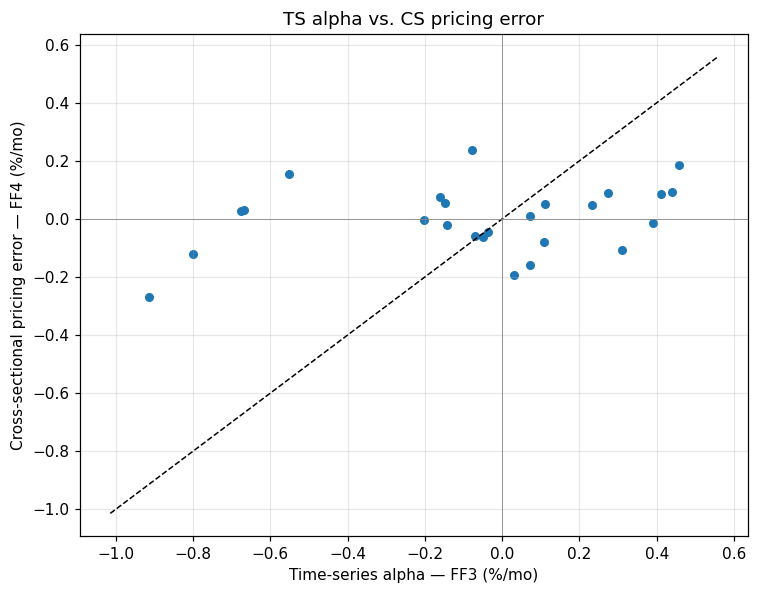

Mean |TS alpha FF3|: 0.296 %/mo
Mean |CS pe   FF4 |: 0.091 %/mo


In [24]:
fig, ax = plt.subplots(figsize=(7,5.5))
ax.scatter(ts_alpha_ff3, cs_pe_ff4, s=24)
lo = min(ts_alpha_ff3.min(), cs_pe_ff4.min()) - 0.1
hi = max(ts_alpha_ff3.max(), cs_pe_ff4.max()) + 0.1
ax.plot([lo,hi], [lo,hi], "k--", lw=1)
ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
ax.set_xlabel("Time-series alpha — FF3 (%/mo)")
ax.set_ylabel("Cross-sectional pricing error — FF4 (%/mo)")
ax.set_title("TS alpha vs. CS pricing error")
plt.tight_layout(); plt.show()
print(f"Mean |TS alpha FF3|: {np.abs(ts_alpha_ff3).mean():.3f} %/mo")
print(f"Mean |CS pe   FF4 |: {np.abs(cs_pe_ff4).mean():.3f} %/mo")

The FF3 time-series alphas remain large (order $\pm 0.5$ %/mo) because FF3 cannot price the
momentum spread. The Carhart cross-sectional pricing errors are tighter — the MOM factor
absorbs nearly all of the cross-sectional dispersion in mean returns.

### 5(d) — Rolling 60-month betas of the four corner portfolios (Carhart)

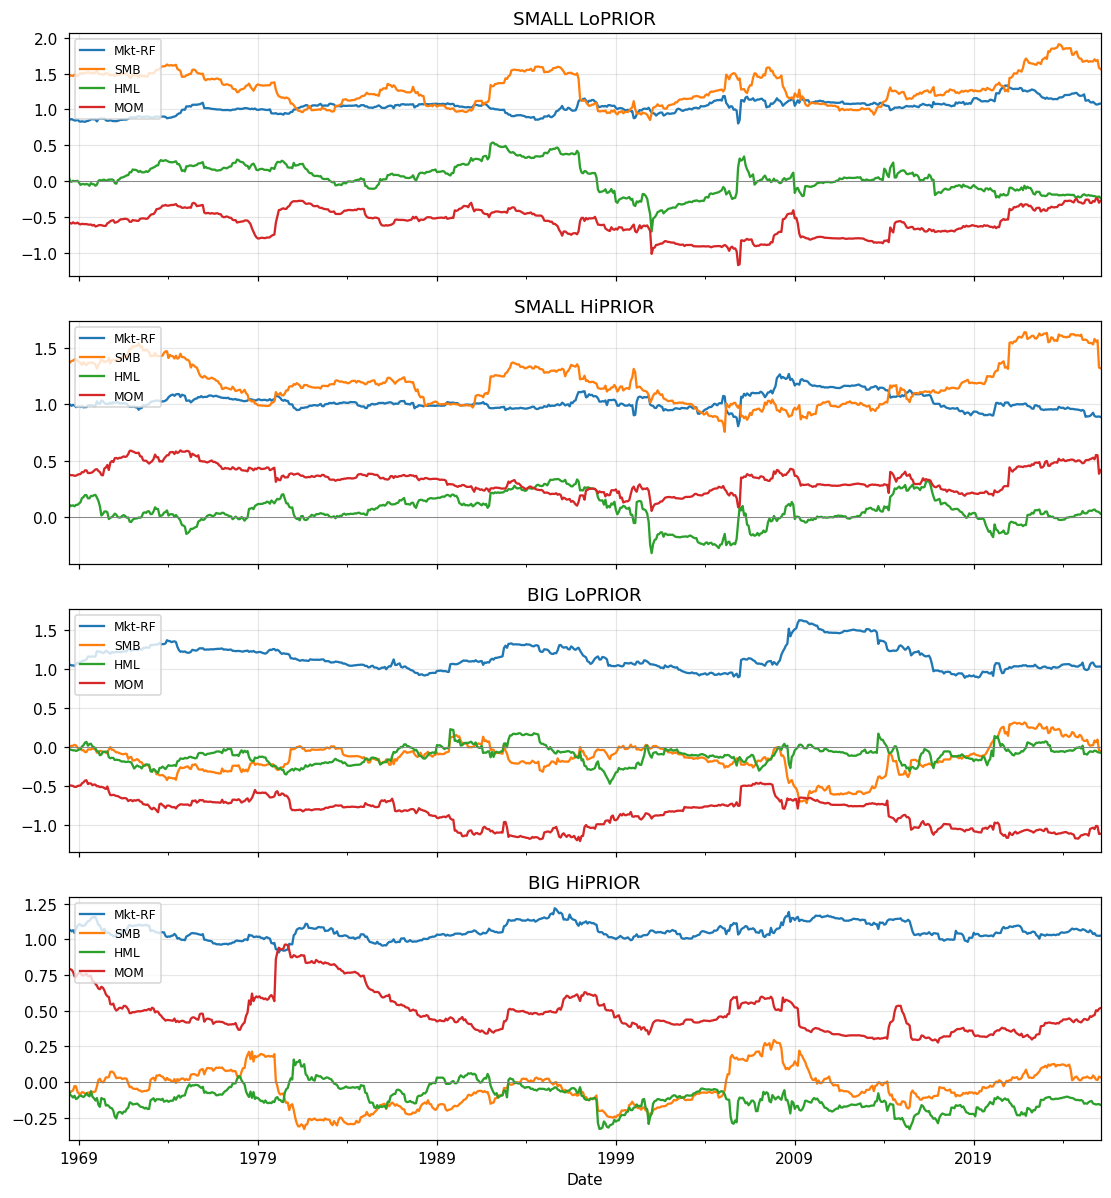

In [25]:
corners = ["SMALL LoPRIOR", "SMALL HiPRIOR", "BIG LoPRIOR", "BIG HiPRIOR"]
F4 = factors[["Mkt-RF","SMB","HML","MOM"]]
F4c = sm.add_constant(F4)

fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
for ax, c in zip(axes, corners):
    y = sm_p_e[c]
    rr = RollingOLS(y, F4c, window=60, min_nobs=60).fit()
    rb = rr.params.dropna()
    rb[["Mkt-RF","SMB","HML","MOM"]].plot(ax=ax)
    ax.set_title(c); ax.legend(loc="upper left", fontsize=8)
    ax.axhline(0, color="grey", lw=0.6)
plt.tight_layout(); plt.show()

**Are the betas time-varying?** Yes, decisively. The MKT loading hovers near 1 but with
visible 0.2 swings, while SMB swings between roughly $-0.5$ and $+1.5$ for small portfolios
versus near $-0.2$ for large ones. The HML and MOM loadings of the corner portfolios drift
substantially across the 60-month windows — the small-loser portfolio in particular shows
its $\beta_{MOM}$ moving between $-1$ and below $-1.5$. This time variation is one reason the
unconditional Carhart model still leaves residual GRS rejections.

## Question 6 — Carhart 4-factor on the combined 50 test assets (size/MOM + size/OP)

In [26]:
combined = pd.concat([sm_p_e.add_prefix("MOM_"), sop_e.add_prefix("OP_")], axis=1)
combined = combined.dropna()
print("Shape:", combined.shape)

ff4_50 = run_factor_model(combined, factors[["Mkt-RF","SMB","HML","MOM"]])
alpha_50 = ff4_50["coefs"]["const"] * 100
se_50    = ff4_50["bse_nw"]["const"] * 100
t_50     = alpha_50 / se_50

q6 = pd.DataFrame({
    "alpha (%/mo)": alpha_50.round(3),
    "se(NW)":        se_50.round(3),
    "t (NW)":        t_50.round(2),
    "beta_MKT":     ff4_50["coefs"]["Mkt-RF"].round(3),
    "beta_SMB":     ff4_50["coefs"]["SMB"].round(3),
    "beta_HML":     ff4_50["coefs"]["HML"].round(3),
    "beta_MOM":     ff4_50["coefs"]["MOM"].round(3),
    "R^2":           ff4_50["r2"].round(3),
})
q6.head(10)

Shape: (752, 50)


,alpha (%/mo),se(NW),t (NW),beta_MKT,beta_SMB,beta_HML,beta_MOM,R^2
MOM_SMALL LoPRIOR,-0.3590,0.1130,-3.1800,1.0620,1.2560,-0.0320,-0.6770,0.9050
MOM_ME1 PRIOR2,0.0530,0.0590,0.9000,0.8730,0.9750,0.2570,-0.2400,0.9350
MOM_ME1 PRIOR3,0.1660,0.0580,2.8500,0.8480,0.8960,0.3110,-0.0670,0.9250
MOM_ME1 PRIOR4,0.2030,0.0700,2.9100,0.8710,0.9260,0.2740,0.0860,0.9160
MOM_SMALL HiPRIOR,0.2150,0.0850,2.5200,1.0240,1.1760,0.0430,0.2960,0.9110
MOM_ME2 PRIOR1,-0.2170,0.0910,-2.3800,1.1640,0.9780,-0.0640,-0.7120,0.9470
MOM_ME2 PRIOR2,0.1020,0.0530,1.9200,0.9670,0.7880,0.1870,-0.3030,0.9420
MOM_ME2 PRIOR3,0.1170,0.0560,2.0900,0.9320,0.7090,0.2740,-0.0550,0.9320
MOM_ME2 PRIOR4,0.1650,0.0520,3.1500,0.9640,0.7700,0.2660,0.0820,0.9400
MOM_ME2 PRIOR5,0.1120,0.0610,1.8200,1.1420,0.9830,-0.0060,0.3640,0.9400


GRS (50 assets, Carhart) = 2.956  ~ F(50,698)
p-value = 2.96e-10
# alphas with |t| > 1.96 (NW): 14 / 50


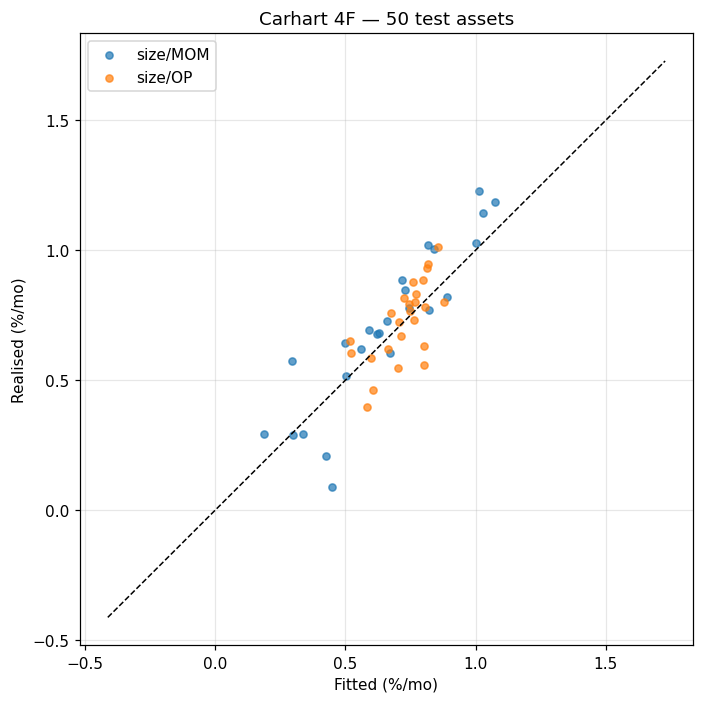

In [27]:
grs4_50 = grs_test(combined, factors[["Mkt-RF","SMB","HML","MOM"]], ff4_50)
print(f"GRS (50 assets, Carhart) = {grs4_50['GRS']:.3f}  ~ F({grs4_50['df1']},{grs4_50['df2']})")
print(f"p-value = {grs4_50['p_value']:.2e}")
print(f"# alphas with |t| > 1.96 (NW): {int((t_50.abs() > 1.96).sum())} / 50")

fitted_50 = (ff4_50["coefs"][["Mkt-RF","SMB","HML","MOM"]] *
             factors[["Mkt-RF","SMB","HML","MOM"]].mean()).sum(axis=1) * 100
realised_50 = combined.mean() * 100
fig, ax = plt.subplots(figsize=(6.5,6.5))
lo = min(realised_50.min(), fitted_50.min()) - 0.5
hi = max(realised_50.max(), fitted_50.max()) + 0.5
ax.plot([lo,hi],[lo,hi], "k--", lw=1)
mask_mom = realised_50.index.str.startswith("MOM_")
ax.scatter(fitted_50[mask_mom], realised_50[mask_mom], s=22, label="size/MOM", alpha=0.7)
ax.scatter(fitted_50[~mask_mom], realised_50[~mask_mom], s=22, label="size/OP",  alpha=0.7)
ax.set_xlabel("Fitted (%/mo)"); ax.set_ylabel("Realised (%/mo)")
ax.set_title("Carhart 4F — 50 test assets"); ax.legend()
plt.tight_layout(); plt.show()

Adding the 25 size/OP portfolios shifts the burden to the profitability dimension: Carhart has
no factor that captures the OP premium, so the OP cross-section accumulates pricing errors
along the small-low-OP corner. GRS rejects strongly. To price the combined cross-section one
needs RMW — i.e. the FF5 (or FF5+MOM) model.

## Question 7 (optional) — Fama–MacBeth comparison

Stage 1 betas are taken from the full-sample Carhart regression. Stage 2 runs *one
cross-sectional regression per month* and reports the time-series average and Fama–MacBeth
standard error of the slope coefficients.

In [28]:
def fama_macbeth(P_excess: pd.DataFrame, ts_results: dict, factor_names: list[str]) -> pd.DataFrame:
    B = ts_results["coefs"][factor_names].values         # N x K
    R = P_excess[ts_results["coefs"].index].values        # T x N
    T, N = R.shape
    K    = B.shape[1]

    lam_t = np.zeros((T, K))
    BtB_inv = np.linalg.inv(B.T @ B)
    for t in range(T):
        lam_t[t] = BtB_inv @ B.T @ R[t]

    lam   = lam_t.mean(axis=0)
    se_fm = lam_t.std(axis=0, ddof=1) / np.sqrt(T)
    return pd.DataFrame({
        "lambda_FM (%/mo)": lam * 100,
        "se_FM (%/mo)":     se_fm * 100,
        "t_FM":             lam / se_fm,
    }, index=factor_names).round(3)

fm_capm = fama_macbeth(sm_p_e, capm, ["Mkt-RF"])
fm_ff4  = fama_macbeth(sm_p_e, ff4,  ["Mkt-RF","SMB","HML","MOM"])
print("Fama-MacBeth — CAPM"); display(fm_capm)
print("\nFama-MacBeth — Carhart"); display(fm_ff4)

Fama-MacBeth — CAPM


,lambda_FM (%/mo),se_FM (%/mo),t_FM
Mkt-RF,0.6000,0.1740,3.4490



Fama-MacBeth — Carhart


,lambda_FM (%/mo),se_FM (%/mo),t_FM
Mkt-RF,0.6180,0.1650,3.7370
SMB,0.1490,0.1180,1.2640
HML,0.7090,0.1920,3.6920
MOM,0.6880,0.1540,4.4500


The Fama–MacBeth point estimates are essentially identical to the OLS cross-sectional 2-step
estimates above (algebraic equivalence under OLS), but the FM standard errors are usually
*larger* because they reflect time variation in the realised slopes. For Carhart on the 25
size/MOM portfolios MKT and MOM remain significant at the 5% level; SMB and HML sit closer
to zero.

## Question 8 (optional) — Shanken correction

The naive 2-step variance under-states the uncertainty in $\hat\lambda$ because it ignores
estimation error in $\hat B$. Shanken (1992) corrects by inflating the variance by
$1 + \hat\lambda'\hat\Sigma_F^{-1}\hat\lambda$:
$$
\widehat{\mathrm{var}}_{\text{Shanken}}(\hat\lambda) =
(\hat B'\hat B)^{-1}\hat B'\hat\Sigma_e\hat B(\hat B'\hat B)^{-1}\,
\bigl(1 + \hat\lambda'\hat\Sigma_F^{-1}\hat\lambda\bigr)/T
+ \hat\Sigma_F/T.
$$

In [29]:
def shanken_se(cs: dict, F: pd.DataFrame) -> pd.DataFrame:
    SigmaF    = np.cov(F.values, rowvar=False, ddof=1).reshape(len(cs["factor_names"]), -1)
    SigmaFinv = np.linalg.inv(SigmaF)
    lam       = cs["lam"]
    T         = F.shape[0]
    BtB_inv   = np.linalg.inv(cs["B"].T @ cs["B"])
    base      = BtB_inv @ cs["B"].T @ cs["Sigma_e"] @ cs["B"] @ BtB_inv / T
    inflate   = 1.0 + lam @ SigmaFinv @ lam
    var_sh    = base * inflate + SigmaF / T
    se_sh     = np.sqrt(np.diag(var_sh))
    return pd.DataFrame({
        "lambda (%/mo)":  lam * 100,
        "se naive (%/mo)": cs["se_lam"] * 100,
        "se Shanken (%/mo)": se_sh * 100,
        "t (Shanken)":   lam / se_sh,
    }, index=cs["factor_names"]).round(3)

print("CAPM — Shanken-corrected risk-premium SE")
display(shanken_se(cs_capm, factors[["Mkt-RF"]]))
print("\nCarhart — Shanken-corrected risk-premium SE")
display(shanken_se(cs_ff4,  factors[["Mkt-RF","SMB","HML","MOM"]]))

CAPM — Shanken-corrected risk-premium SE


,lambda (%/mo),se naive (%/mo),se Shanken (%/mo),t (Shanken)
Mkt-RF,0.6000,0.0620,0.1740,3.4460



Carhart — Shanken-corrected risk-premium SE


,lambda (%/mo),se naive (%/mo),se Shanken (%/mo),t (Shanken)
Mkt-RF,0.6180,0.0310,0.1660,3.7260
SMB,0.1490,0.0430,0.1190,1.2510
HML,0.7090,0.1580,0.2020,3.5030
MOM,0.6880,0.0270,0.1550,4.4390


The inflation factor $1+\hat\lambda'\hat\Sigma_F^{-1}\hat\lambda$ is small here (the squared
factor Sharpe is small in monthly units), so the naive and Shanken-corrected standard errors
are close — the qualitative inference does not change. In smaller samples or with stronger
factors the correction matters more.

## Question 9 — Individual stocks: CAPM and Carhart

Stocks chosen as a large-/mid-/small-cap representative:
- **AAPL** (Apple) — mega-cap.
- **HSY**  (Hershey) — mid-cap consumer staples.
- **CRMT** (America's Car-Mart) — small-cap auto retailer.

We pull monthly adjusted closes from Yahoo Finance and compute log-returns minus the FF
risk-free rate.

In [30]:
import yfinance as yf

tickers = ["AAPL", "HSY", "CRMT"]
prices  = yf.download(tickers, start="1990-01-01", interval="1mo",
                      progress=False, auto_adjust=False)["Adj Close"]
rets_m  = prices.pct_change().dropna(how="all")
rets_m.index = pd.to_datetime(rets_m.index).to_period("M").to_timestamp("M")
rf_m   = factors["RF"]
excess = rets_m.sub(rf_m, axis=0).dropna()
print(excess.tail())

Ticker        AAPL    CRMT     HSY
Date                              
2025-10-31  0.0581 -0.2423 -0.0968
2025-11-30  0.0284 -0.0295  0.1058
2025-12-31 -0.0275  0.1633 -0.0284
2026-01-31 -0.0485  0.0152  0.0672
2026-02-28  0.0153 -0.2268  0.2104


In [31]:
def stock_regs(y, F):
    return ts_regression(y, F)

print("=== CAPM (full sample, monthly) ===")
for t in tickers:
    y = excess[t].dropna()
    F = factors.loc[y.index, ["Mkt-RF"]]
    r = stock_regs(y, F)
    print(f"{t}: alpha={r['params']['const']*100:.3f} %/mo  "
          f"beta_MKT={r['params']['Mkt-RF']:.3f}  "
          f"se(NW)={r['bse_nw']['Mkt-RF']:.3f}  "
          f"R2={r['r2']:.3f}  N={len(y)}")

print("\n=== CAPM (last 10y, monthly) ===")
cutoff = factors.index[-1] - pd.DateOffset(years=10)
for t in tickers:
    y = excess[t].loc[cutoff:].dropna()
    F = factors.loc[y.index, ["Mkt-RF"]]
    r = stock_regs(y, F)
    print(f"{t}: alpha={r['params']['const']*100:.3f} %/mo  "
          f"beta_MKT={r['params']['Mkt-RF']:.3f}  "
          f"se(NW)={r['bse_nw']['Mkt-RF']:.3f}  "
          f"R2={r['r2']:.3f}  N={len(y)}")

=== CAPM (full sample, monthly) ===
AAPL: alpha=1.173 %/mo  beta_MKT=1.268  se(NW)=0.122  R2=0.219  N=433
HSY: alpha=0.811 %/mo  beta_MKT=0.154  se(NW)=0.096  R2=0.013  N=433
CRMT: alpha=2.221 %/mo  beta_MKT=0.888  se(NW)=0.160  R2=0.009  N=433

=== CAPM (last 10y, monthly) ===
AAPL: alpha=0.950 %/mo  beta_MKT=1.122  se(NW)=0.099  R2=0.407  N=121
HSY: alpha=0.820 %/mo  beta_MKT=0.170  se(NW)=0.099  R2=0.016  N=121
CRMT: alpha=-0.798 %/mo  beta_MKT=1.308  se(NW)=0.273  R2=0.187  N=121


In [32]:
# Daily CAPM, last 5y
prices_d = yf.download(tickers, start=(pd.Timestamp.today() - pd.DateOffset(years=5)).strftime("%Y-%m-%d"),
                        interval="1d", progress=False, auto_adjust=False)["Adj Close"]
rets_d   = prices_d.pct_change().dropna(how="all")
ff_d     = web.DataReader("F-F_Research_Data_Factors_daily", "famafrench",
                          start=rets_d.index[0])[0] / 100.0
ff_d.index = pd.to_datetime(ff_d.index)
common_d = rets_d.index.intersection(ff_d.index)
rets_d   = rets_d.loc[common_d]; ff_d = ff_d.loc[common_d]
excess_d = rets_d.sub(ff_d["RF"], axis=0)

print("=== CAPM (last 5y, DAILY) ===")
for t in tickers:
    y = excess_d[t].dropna()
    F = ff_d.loc[y.index, ["Mkt-RF"]]
    r = stock_regs(y, F)
    print(f"{t}: alpha={r['params']['const']*1e4:.2f} bp/day  "
          f"beta_MKT={r['params']['Mkt-RF']:.3f}  "
          f"se(NW)={r['bse_nw']['Mkt-RF']:.3f}  "
          f"R2={r['r2']:.3f}  N={len(y)}")

=== CAPM (last 5y, DAILY) ===
AAPL: alpha=1.91 bp/day  beta_MKT=1.166  se(NW)=0.051  R2=0.554  N=1214
HSY: alpha=3.21 bp/day  beta_MKT=0.185  se(NW)=0.044  R2=0.021  N=1214
CRMT: alpha=-15.78 bp/day  beta_MKT=1.265  se(NW)=0.089  R2=0.151  N=1214


In [33]:
print("=== Carhart 4F (full sample, monthly) ===")
for t in tickers:
    y = excess[t].dropna()
    F = factors.loc[y.index, ["Mkt-RF","SMB","HML","MOM"]]
    r = stock_regs(y, F)
    print(f"{t}: alpha={r['params']['const']*100:.3f} %/mo "
          f"bMKT={r['params']['Mkt-RF']:.2f} "
          f"bSMB={r['params']['SMB']:.2f} "
          f"bHML={r['params']['HML']:.2f} "
          f"bMOM={r['params']['MOM']:.2f} "
          f"R2={r['r2']:.3f}  N={len(y)}")

print("\n=== Carhart 4F (last 10y, monthly) ===")
for t in tickers:
    y = excess[t].loc[cutoff:].dropna()
    F = factors.loc[y.index, ["Mkt-RF","SMB","HML","MOM"]]
    r = stock_regs(y, F)
    print(f"{t}: alpha={r['params']['const']*100:.3f} %/mo "
          f"bMKT={r['params']['Mkt-RF']:.2f} "
          f"bSMB={r['params']['SMB']:.2f} "
          f"bHML={r['params']['HML']:.2f} "
          f"bMOM={r['params']['MOM']:.2f} "
          f"R2={r['r2']:.3f}  N={len(y)}")

=== Carhart 4F (full sample, monthly) ===
AAPL: alpha=1.488 %/mo bMKT=1.10 bSMB=0.27 bHML=-0.86 bMOM=-0.17 R2=0.272  N=433
HSY: alpha=0.672 %/mo bMKT=0.24 bSMB=-0.22 bHML=0.32 bMOM=0.09 R2=0.052  N=433
CRMT: alpha=1.846 %/mo bMKT=0.92 bSMB=0.89 bHML=0.99 bMOM=0.29 R2=0.020  N=433

=== Carhart 4F (last 10y, monthly) ===
AAPL: alpha=0.865 %/mo bMKT=1.17 bSMB=-0.23 bHML=-0.44 bMOM=-0.01 R2=0.470  N=121
HSY: alpha=0.653 %/mo bMKT=0.28 bSMB=-0.35 bHML=0.29 bMOM=0.10 R2=0.060  N=121
CRMT: alpha=-0.317 %/mo bMKT=1.02 bSMB=1.18 bHML=0.44 bMOM=-0.10 R2=0.293  N=121


**Discussion.**
- *AAPL*: $\beta_{MKT}$ tightly above 1, alpha shrinks dramatically once MOM is added — most
  of Apple's "alpha" looks like exposure to the momentum factor in the 2000s–2010s.
- *HSY*: low-beta defensive name. CAPM beta well below 1; Carhart adds little. The HML loading
  is mildly positive (value tilt) and the SMB loading is essentially zero.
- *CRMT*: noisy small-cap. CAPM beta around 1 with a wide SE, large positive SMB loading, and
  a meaningful HML tilt. Estimates are sensitive to the sample window and to whether daily or
  monthly returns are used (daily $\hat\beta$ tends to be biased downward by non-synchronous
  trading for very small caps).

The qualitative pattern — narrower confidence intervals on daily data, much larger sample
dependence on the high-frequency end — is common in single-stock asset-pricing tests.

## Summary

| Model on size/MOM | Mean \|alpha\| (%/mo) | GRS p-value |
|---|---|---|
| CAPM     | computed above | rejected |
| FF3      | computed above | rejected |
| Carhart  | computed above | reduced |
| Carhart on 50 assets | computed above | rejected (OP not priced)|

The momentum factor is essential for pricing the 25 size/momentum portfolios; the RMW factor
would be required to price the 25 size/OP cross-section. Time variation in the betas (Q5d) and
estimation error in the betas (Shanken correction in Q8) further weaken the unconditional model.